In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping

import numpy as np
import matplotlib.pyplot as plt
import cv2

from imblearn.over_sampling import SMOTE #for handling imbalanced data

import os
import pathlib

In [2]:
train_data=pathlib.Path("DataSet_Major_Project/Brain_Stroke/stroke_noncropped/NON_CROPPED/TRAIN/")
test_data=pathlib.Path("DataSet_Major_Project/Brain_Stroke/stroke_noncropped/NON_CROPPED/TEST/")
val_data=pathlib.Path("DataSet_Major_Project/Brain_Stroke/stroke_noncropped/NON_CROPPED/VAL/")

In [3]:
list(train_data.glob("*/*.jpg"))[0:5]

[WindowsPath('DataSet_Major_Project/Brain_Stroke/stroke_noncropped/NON_CROPPED/TRAIN/NORMAL/100 (1).jpg'),
 WindowsPath('DataSet_Major_Project/Brain_Stroke/stroke_noncropped/NON_CROPPED/TRAIN/NORMAL/100 (10).jpg'),
 WindowsPath('DataSet_Major_Project/Brain_Stroke/stroke_noncropped/NON_CROPPED/TRAIN/NORMAL/100 (13).jpg'),
 WindowsPath('DataSet_Major_Project/Brain_Stroke/stroke_noncropped/NON_CROPPED/TRAIN/NORMAL/100 (16).jpg'),
 WindowsPath('DataSet_Major_Project/Brain_Stroke/stroke_noncropped/NON_CROPPED/TRAIN/NORMAL/100 (17).jpg')]

In [4]:
MRI_images_dict={
    "Normal":list(train_data.glob("Normal/*"))+list(val_data.glob("Normal/*"))+list(test_data.glob("Normal/*")),
    "Stroke":list(train_data.glob("Stroke/*"))+list(val_data.glob("Stroke/*"))+list(test_data.glob("Normal/*"))
}

In [5]:
len(MRI_images_dict["Stroke"])

789

In [6]:
len(MRI_images_dict["Normal"])#we can see imbalanced data

1087

In [7]:
Stroke_label_dict={
    "Normal":0,
    "Stroke":1
}

In [8]:
cv2.imread(str(MRI_images_dict["Stroke"][100])).shape

(650, 650, 3)

In [9]:
X,y=[],[]

for categoryName,categoryImages in MRI_images_dict.items():
    for image in categoryImages:
        img=cv2.imread(str(image))
        resized=cv2.resize(img,(240,240))
        X.append(resized)
        y.append(Stroke_label_dict[categoryName])
        

In [10]:
X=np.array(X)
y=np.array(y)

In [11]:
X.max()

255

## Scalling

In [12]:
X=X/255

In [13]:
X.max()

1.0

# Handling Imbalanced Data

## SMOTE

In [14]:
X1 = np.reshape(X, (X.shape[0], -1))
X1.shape

(1876, 172800)

In [15]:
smote = SMOTE(sampling_strategy='auto')
X_sm, y_sm = smote.fit_resample(X1, y)

X_sm = np.reshape(X_sm, (X_sm.shape[0], 240, 240, 3))

In [16]:
X=X_sm
y=y_sm

In [17]:
X.shape

(2174, 240, 240, 3)

In [18]:
normal_count=0
stroke_count=0
for i in y:
    if i==0:
        normal_count=normal_count+1
    elif i==1:
        stroke_count=stroke_count+1


print("Total no. normal images: "+str(normal_count))
print("\nTotal no. brain stroke images: "+str(stroke_count))

Total no. normal images: 1087

Total no. brain stroke images: 1087


## Data Augmentation

In [19]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen=ImageDataGenerator(rotation_range=15,
                          width_shift_range=0.1,
                          height_shift_range=0.1,
                          shear_range=0.2,
                          zoom_range=0.2,
                          horizontal_flip=True,
                          vertical_flip=True,
                          fill_mode='nearest')

augmented_data=datagen.flow(X,y,batch_size=len(X),shuffle=False)

augmented_images,augmented_labels=next(augmented_data)

augmented_images=np.array(augmented_images)
augmented_labels=np.array(augmented_labels)

In [35]:
save_dir='augmented_images_brain_stroke'
os.makedirs(save_dir,exist_ok=True)

for i,img in enumerate(augmented_images):
    if augmented_labels[i]==0:
        name="Normal"
    else :
        name="Stroke"
    file_name=os.path.join(save_dir,f'{name}{i}.jpg')
    tf.keras.preprocessing.image.save_img(file_name,img)

In [20]:
augmented_images.max()

1.0

In [21]:
augmented_images.shape

(2174, 240, 240, 3)

In [22]:
X=np.concatenate((X,augmented_images),axis=0)
y=np.concatenate((y,augmented_labels),axis=0)

In [23]:
X.shape

(4348, 240, 240, 3)

# Viewing image data

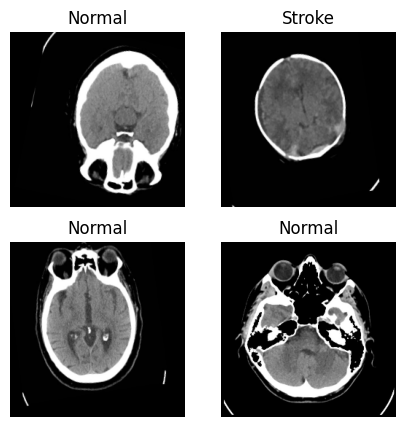

In [27]:
def getCategoryName(n):
    for x,y in Stroke_label_dict.items():
        if y==n:
            return x


plt.figure(figsize=(5,5))
for n,i in enumerate(list(np.random.randint(0,len(X),4))):
    plt.subplot(2,2,n+1)
    plt.imshow(X[i])
    plt.axis('Off')
    plt.title(getCategoryName(y[i]))

## Spitting data

In [45]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

MemoryError: Unable to allocate 4.48 GiB for an array with shape (3478, 240, 240, 3) and data type float64

In [27]:
X_train.shape

(3478, 180, 180, 3)

In [28]:
X_test.shape

(870, 180, 180, 3)

In [29]:
y_train.shape

(3478,)

# Creating neural network model

In [32]:
model = Sequential()

model.add(layers.Conv2D(filters=100,kernel_size=(3,3),strides=(1,1),padding="valid",activation="relu", input_shape=(180,180,3)))
model.add(layers.MaxPooling2D(pool_size=(2,2)))

model.add(layers.Conv2D(filters=80,kernel_size=(3,3),strides=(1,1),padding="valid",activation="relu"))
model.add(layers.MaxPooling2D(pool_size=(2,2)))

model.add(layers.Conv2D(filters=64,kernel_size=(3,3),strides=(1,1),padding="valid",activation="relu"))
model.add(layers.MaxPooling2D(pool_size=(2,2)))

model.add(layers.Flatten())
model.add(layers.Dense(units=500, activation="relu"))
model.add(layers.Dropout(0.2))
model.add(layers.Dense(units=500, activation="relu"))
model.add(layers.Dropout(0.2))
model.add(layers.Dense(units=1, activation="sigmoid"))

model.compile(optimizer="adam",loss="binary_crossentropy",
             metrics=["accuracy"])

model.summary()


Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_3 (Conv2D)           (None, 178, 178, 100)     2800      
                                                                 
 max_pooling2d_3 (MaxPoolin  (None, 89, 89, 100)       0         
 g2D)                                                            
                                                                 
 conv2d_4 (Conv2D)           (None, 87, 87, 80)        72080     
                                                                 
 max_pooling2d_4 (MaxPoolin  (None, 43, 43, 80)        0         
 g2D)                                                            
                                                                 
 conv2d_5 (Conv2D)           (None, 41, 41, 64)        46144     
                                                                 
 max_pooling2d_5 (MaxPoolin  (None, 20, 20, 64)       

In [33]:
model=Sequential([
    layers.Conv2D(filters=64,kernel_size=(3,3),input_shape=(180,180,3),activation='relu'),
    layers.MaxPool2D((2,2)),
    
    layers.Flatten(),
    layers.Dense(32,activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(16,activation='relu'),
    layers.Dense(1,activation='sigmoid') #2 classes      
])

model.compile(optimizer='adam',
               loss='binary_crossentropy',
               metrics=['accuracy'])

earlyStopping=EarlyStopping(monitor='val_loss',
                           patience=3,
                           restore_best_weights=True)

In [33]:
earlyStopping=EarlyStopping(monitor='val_loss',
                           patience=3,
                           restore_best_weights=True)

In [34]:
history=model.fit(X_train,y_train,
                  epochs=20,
                  validation_data=(X_test,y_test),
                  callbacks=[earlyStopping])


Epoch 1/20
109/109 [==============================] - 242s 2s/step - loss: 0.6830 - accuracy: 0.5535 - val_loss: 0.6427 - val_accuracy: 0.6276
Epoch 2/20
109/109 [==============================] - 233s 2s/step - loss: 0.6001 - accuracy: 0.6748 - val_loss: 0.6179 - val_accuracy: 0.6391
Epoch 3/20
109/109 [==============================] - 232s 2s/step - loss: 0.4708 - accuracy: 0.7780 - val_loss: 0.6127 - val_accuracy: 0.6885
Epoch 4/20
109/109 [==============================] - 232s 2s/step - loss: 0.3548 - accuracy: 0.8516 - val_loss: 0.6729 - val_accuracy: 0.6851
Epoch 5/20
109/109 [==============================] - 232s 2s/step - loss: 0.2318 - accuracy: 0.9089 - val_loss: 0.8279 - val_accuracy: 0.7057
Epoch 6/20
109/109 [==============================] - 232s 2s/step - loss: 0.1710 - accuracy: 0.9373 - val_loss: 0.9839 - val_accuracy: 0.6989


<function matplotlib.pyplot.show(close=None, block=None)>

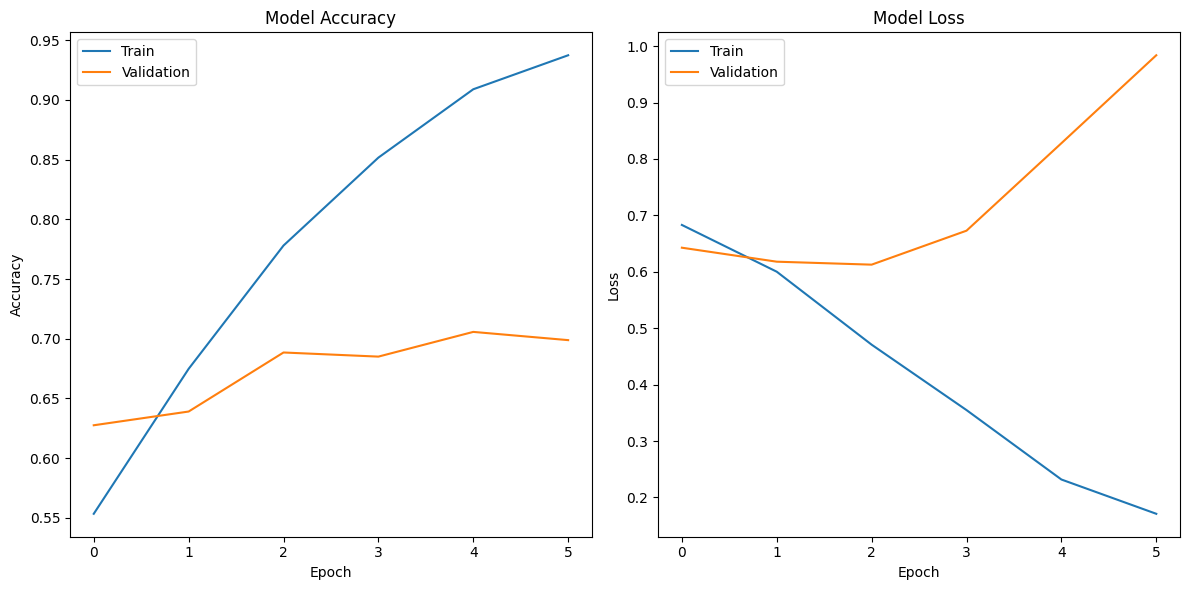

In [35]:

#Accuracy garph
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train",'Validation'],loc='upper left')

#loss graph
plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train",'Validation'],loc='upper left')
plt.tight_layout()
plt.show
